#Étude de marché


In [ ]:
#Import des bibliothèque NumPy, Pandas et Matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 2) Charger les CSV BRUTS
df_dispoalim = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P11/DisponibiliteAlimentaire_2017.csv")
df_population = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/P11/Population_2000_2018.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Analyse df_disponibilité alimentaire 2017

In [ ]:
df_dispoalim.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


In [ ]:
df_population.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


In [ ]:
df_dispoalim["Élément"].unique()

array(['Production', 'Importations - Quantité', 'Variation de stock',
       'Exportations - Quantité', 'Disponibilité intérieure',
       'Aliments pour animaux', 'Semences', 'Pertes', 'Résidus',
       'Nourriture',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Traitement', 'Autres utilisations (non alimentaire)',
       'Alimentation pour touristes'], dtype=object)

##Sélection des variables pertinentes

Le jeu de données de disponibilité alimentaire contient de nombreux indicateurs et produits alimentaires.

Dans le cadre de cette étude, seules les variables jugées pertinentes pour l’analyse du marché de la volaille ont été conservées :

- Production
- Importations
- Exportations
- Disponibilité intérieure
- Disponibilité alimentaire en quantité
- Disponibilité alimentaire en Kcal/personne/jour

Les variables trop spécifiques ou redondantes ont été écartées afin de simplifier l’analyse et limiter les corrélations inutiles.

In [ ]:
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411 entries, 0 to 4410
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            4411 non-null   object 
 1   Domaine                 4411 non-null   object 
 2   Code zone               4411 non-null   int64  
 3   Zone                    4411 non-null   object 
 4   Code Élément            4411 non-null   int64  
 5   Élément                 4411 non-null   object 
 6   Code Produit            4411 non-null   int64  
 7   Produit                 4411 non-null   object 
 8   Code année              4411 non-null   int64  
 9   Année                   4411 non-null   int64  
 10  Unité                   4411 non-null   object 
 11  Valeur                  4411 non-null   float64
 12  Symbole                 4411 non-null   object 
 13  Description du Symbole  4411 non-null   object 
 14  Note                    258 non-null    

In [ ]:
df_population["Élément"].unique()

array(['Population totale'], dtype=object)

## Sélection des variables liées au marché de la volaille

Les variables de production, importations, exportations et disponibilité intérieure sont conservées pour la viande de volailles.

Elles décrivent directement le marché de la volaille dans chaque pays.

In [ ]:
variables_volaille = [
    'Production',
    'Importations - Quantité',
    'Exportations - Quantité',
    'Disponibilité intérieure'
]

df_volaille = df_dispoalim[
    (df_dispoalim['Produit'] == 'Viande de Volailles') &
    (df_dispoalim['Élément'].isin(variables_volaille))
][['Zone', 'Élément', 'Valeur']]

## Transformation des données par pivot
Les variables étant initialement stockées sous forme de lignes dans la colonne "Élément", une transformation par pivot a été réalisée.

Cette étape permet d’obtenir :
- une ligne par pays ;
- une colonne par variable ;

format nécessaire pour les analyses statistiques multivariées comme le clustering.

In [ ]:
df_volaille_pivot = df_volaille.pivot_table(
    index='Zone',
    columns='Élément',
    values='Valeur')

df_volaille_pivot.head()

Élément,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production
Zone,,,,
Afghanistan,57.0,NaN,29.0,28.0
Afrique du Sud,2118.0,63.0,514.0,1667.0
Albanie,47.0,0.0,38.0,13.0
Algérie,277.0,0.0,2.0,275.0
Allemagne,1739.0,646.0,842.0,1514.0


In [ ]:
df_volaille_pivot = df_volaille_pivot.reset_index()

In [ ]:
df_volaille_pivot.isnull().sum()

,0
Élément,
Zone,0
Disponibilité intérieure,0
Exportations - Quantité,35
Importations - Quantité,0
Production,2


In [ ]:
df_volaille_pivot = df_volaille_pivot.fillna(0)

In [ ]:
#verification des variables df_dispoalim
df_dispoalim["Élément"].unique()


array(['Production', 'Importations - Quantité', 'Variation de stock',
       'Exportations - Quantité', 'Disponibilité intérieure',
       'Aliments pour animaux', 'Semences', 'Pertes', 'Résidus',
       'Nourriture',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Traitement', 'Autres utilisations (non alimentaire)',
       'Alimentation pour touristes'], dtype=object)

In [ ]:
#Exclusion de quelques variables
variables_gardees = [
    'Production',
    'Importations - Quantité',
    'Exportations - Quantité',
    'Disponibilité intérieure',
    'Autres utilisations (non alimentaire)',
    'Disponibilité alimentaire en quantité (kg/personne/an)',
    'Disponibilité alimentaire (Kcal/personne/jour)']

df_dispo_selection = df_dispoalim[
    df_dispoalim['Élément'].isin(variables_gardees)]

In [ ]:
df_dispo_selection.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.00,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.00,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.00,S,Données standardisées
10,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,645,Disponibilité alimentaire en quantité (kg/pers...,2511,Blé et produits,2017,2017,kg,155.39,Fc,Donnée calculée


## Création d'un ratio de consommation de volaille

L'entreprise souhaitant exporter des poulets, l'analyse est centrée sur la **viande de volailles**.

Afin de comparer les pays de manière plus pertinente, un ratio est calculé :

- **Ratio kcal = Disponibilité alimentaire de la viande de volailles / Disponibilité alimentaire totale**
- **Ratio kg = Disponibilité alimentaire de la viande de volailles / Disponibilité alimentaire totale en quantité**

Ces indicateurs mesurent la part de la volaille dans l'alimentation de chaque pays.

In [ ]:
# Filtre sur les kcal
df_kcal = df_dispo_selection[
    df_dispo_selection["Élément"] == "Disponibilité alimentaire (Kcal/personne/jour)"]

In [ ]:
#Le total des kcal par pays
kcal_totales = (
    df_kcal
    .groupby("Zone")["Valeur"]
    .sum()
    .reset_index()
    .rename(columns={"Valeur": "kcal_totales"}))

In [ ]:
# Sélectionner uniquement la viande de volailles
kcal_volaille = (
    df_kcal[df_kcal["Produit"] == "Viande de Volailles"]
    .groupby("Zone")["Valeur"]
    .sum()
    .reset_index()
    .rename(columns={"Valeur": "kcal_volaille"}))

In [ ]:
# Fusion et calcul du ratio
ratio_kcal = kcal_totales.merge(kcal_volaille, on="Zone", how="inner")

ratio_kcal["Part_kcal_volaille (%)"] = (
    ratio_kcal["kcal_volaille"] / ratio_kcal["kcal_totales"] * 100
).round(2)

In [ ]:
# Garder uniquement la colonne utile Zone et Part_kcal_volaille
ratio_kcal = ratio_kcal[["Zone", "Part_kcal_volaille (%)"]]

In [ ]:
#filtre sur la volaille
df_kcal_volailles_filtered = df_kcal[
    df_kcal["Produit"] == "Viande de Volailles"]

In [ ]:
ratio_kcal.head()

,Zone,Part_kcal_volaille (%)
0,Afghanistan,0.25
1,Afrique du Sud,4.79
2,Albanie,2.50
3,Algérie,0.66
4,Allemagne,1.99


In [ ]:
# Filtre sur les kg
df_kg = df_dispo_selection[
    df_dispo_selection["Élément"] == "Disponibilité alimentaire en quantité (kg/personne/an)"]

In [ ]:
# Total kg par pays
kg_totaux = (
    df_kg
    .groupby("Zone")["Valeur"]
    .sum()
    .reset_index()
    .rename(columns={"Valeur": "kg_totaux"}))

In [ ]:
# Kg de volaille par pays
kg_volaille = (
    df_kg[df_kg["Produit"] == "Viande de Volailles"]
    .groupby("Zone")["Valeur"]
    .sum()
    .reset_index()
    .rename(columns={"Valeur": "kg_volaille"})
)

In [ ]:
# Fusion et calcul du ratio
ratio_kg = kg_totaux.merge(kg_volaille, on="Zone", how="inner")

ratio_kg["Part_kg_volaille (%)"] = (
    ratio_kg["kg_volaille"] / ratio_kg["kg_totaux"] * 100
).round(2)

In [ ]:
# Garder uniquement la colonne utile pour la suite
ratio_kg = ratio_kg[["Zone", "Part_kg_volaille (%)"]]

In [ ]:
ratio_kg.head()

,Zone,Part_kg_volaille (%)
0,Afghanistan,0.43
1,Afrique du Sud,6.41
2,Albanie,1.30
3,Algérie,0.80
4,Allemagne,2.06


#Analyse df_population

In [ ]:
df_population["Année"].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018])

In [ ]:
df_population_2017 = df_population[
    df_population["Année"] == 2017]

df_population_2017["Année"].unique()

array([2017])

In [ ]:
df_population_2017.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
17,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,36296.113,X,Sources internationales sûres,NaN
36,OA,Séries temporelles annuelles,202,Afrique du Sud,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,57009.756,X,Sources internationales sûres,NaN
55,OA,Séries temporelles annuelles,3,Albanie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,2884.169,X,Sources internationales sûres,NaN
74,OA,Séries temporelles annuelles,4,Algérie,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,41389.189,X,Sources internationales sûres,NaN
93,OA,Séries temporelles annuelles,79,Allemagne,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,82658.409,X,Sources internationales sûres,NaN


## Préparation des données de population

Les données de population ont été filtrées sur l’année 2017 afin de conserver une cohérence temporelle avec les données de disponibilité alimentaire.

Seules les colonnes utiles à l’analyse ont été conservées :
- Zone
- Population

La colonne "Valeur" a été renommée en "Population" afin d’améliorer la lisibilité du jeu de données.

In [ ]:
df_population_2017 = df_population_2017[
    ['Zone', 'Valeur']]

In [ ]:
df_population_2017 = df_population_2017.rename(
    columns={'Valeur': 'Population'})

In [ ]:
df_population_2017.head()

,Zone,Population
17,Afghanistan,36296.113
36,Afrique du Sud,57009.756
55,Albanie,2884.169
74,Algérie,41389.189
93,Allemagne,82658.409


#Fusion des jeux de données

Les données de disponibilité alimentaire et les données de population ont ensuite été fusionnées à l’aide de la colonne "Zone".

In [ ]:
df_final = df_volaille_pivot.merge(
    ratio_kcal,
    on="Zone",
    how="inner")

df_final = df_final.merge(
    ratio_kg,
    on="Zone",
    how="inner")

df_final.head()

,Zone,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%)
0,Afghanistan,57.0,0.0,29.0,28.0,0.25,0.43
1,Afrique du Sud,2118.0,63.0,514.0,1667.0,4.79,6.41
2,Albanie,47.0,0.0,38.0,13.0,2.50,1.30
3,Algérie,277.0,0.0,2.0,275.0,0.66,0.80
4,Allemagne,1739.0,646.0,842.0,1514.0,1.99,2.06


In [ ]:
df_final = df_final.merge(df_population_2017, on="Zone", how="inner")

In [ ]:
colonnes_a_supprimer = [
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Disponibilité alimentaire en quantité (kg/personne/an)",
]

df_final = df_final.drop(columns=colonnes_a_supprimer, errors='ignore')

In [ ]:
df_final.head()

,Zone,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population
0,Afghanistan,57.0,0.0,29.0,28.0,0.25,0.43,36296.113
1,Afrique du Sud,2118.0,63.0,514.0,1667.0,4.79,6.41,57009.756
2,Albanie,47.0,0.0,38.0,13.0,2.50,1.30,2884.169
3,Algérie,277.0,0.0,2.0,275.0,0.66,0.80,41389.189
4,Allemagne,1739.0,646.0,842.0,1514.0,1.99,2.06,82658.409


#Sélection de nouvelles variables (approche PESTEL)

Afin d’enrichir l’analyse des pays, plusieurs variables externes ont été sélectionnées à partir d’une réflexion basée sur la méthode PESTEL.

L’objectif est d’intégrer des dimensions économiques, démographiques et politiques pouvant influencer le potentiel d’exportation de produits agroalimentaires biologiques.

Les variables retenues sont les suivantes :

- PIB par habitant : évaluer le pouvoir d’achat des consommateurs ; (https://donnees.banquemondiale.org/indicateur/NY.GDP.PCAP.CD)
- Taux d’urbanisation : mesurer le niveau de concentration urbaine et le potentiel logistique ;
- politique : identifier les pays présentant un environnement commercial plus sécurisé.

Ces données sont récupérées depuis des sources open data telles que la Banque mondiale et les indicateurs mondiaux de gouvernance.

### Définition de l’analyse PESTEL

L’analyse PESTEL est une méthode utilisée pour étudier l’environnement externe d’un marché ou d’une entreprise.

Elle permet d’identifier différents facteurs pouvant influencer une activité économique à travers six dimensions :

- Politique
- Économique
- Socioculturelle
- Technologique
- Environnementale
- Légale

Dans cette étude, l’approche PESTEL a été utilisée afin de sélectionner des variables pertinentes pour évaluer le potentiel d’exportation de produits agroalimentaires biologiques selon les pays.

#Analyse df_PIB par habitant

In [ ]:
df_pib = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/P11/API_NY.GDP.PCAP.CD_DS2_fr_csv_v2_601.csv",
    skiprows=4)#ignorer les 4 premières lignes.

df_pib.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,NaN,AFE,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,NaN,AFW,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,PIB par habitant ($ US courants),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [ ]:
df_pib_2017 = df_pib[
    ['Country Name', '2017']]

df_pib_2017.head()

,Country Name,2017
0,Aruba,28440.041688
1,NaN,1528.104224
2,Afghanistan,525.469771
3,NaN,1574.230564
4,Angola,2790.718869


In [ ]:
df_pib_2017 = df_pib_2017.rename(
    columns={
        'Country Name': 'Zone',
        '2017': 'PIB par habitant'})

In [ ]:
df_pib_2017 = df_pib_2017.dropna(subset=['Zone'])
#supprimer les lignes qui ne sont pas des pays.

df_pib_2017.head()

,Zone,PIB par habitant
0,Aruba,28440.041688
2,Afghanistan,525.469771
4,Angola,2790.718869
5,Albanie,5006.360130
6,Andorre,40672.971742


In [ ]:
df_pib_2017.isnull().sum()

,0
Zone,0
PIB par habitant,7


## Préparation de la variable PIB par habitant

La variable PIB par habitant a été extraite pour l’année 2017 afin de rester cohérente avec les données alimentaires.

Quelques valeurs manquantes sont présentes après nettoyage. Elles seront traitées avant l’analyse multivariée, notamment lors de la préparation des données pour l’ACP et le clustering.

In [ ]:
df_final = pd.merge(
    df_final,
    df_pib_2017,
    on='Zone',
    how='inner')
df_final.head()

,Zone,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant
0,Afghanistan,57.0,0.0,29.0,28.0,0.25,0.43,36296.113,525.469771
1,Afrique du Sud,2118.0,63.0,514.0,1667.0,4.79,6.41,57009.756,6618.335083
2,Albanie,47.0,0.0,38.0,13.0,2.50,1.30,2884.169,5006.360130
3,Algérie,277.0,0.0,2.0,275.0,0.66,0.80,41389.189,4554.667540
4,Allemagne,1739.0,646.0,842.0,1514.0,1.99,2.06,82658.409,45553.934150


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Zone                      151 non-null    object 
 1   Disponibilité intérieure  151 non-null    float64
 2   Exportations - Quantité   151 non-null    float64
 3   Importations - Quantité   151 non-null    float64
 4   Production                151 non-null    float64
 5   Part_kcal_volaille (%)    151 non-null    float64
 6   Part_kg_volaille (%)      151 non-null    float64
 7   Population                151 non-null    float64
 8   PIB par habitant          151 non-null    float64
dtypes: float64(8), object(1)
memory usage: 10.7+ KB


#Analyse df_urban_popu

In [ ]:
df_urban_popu = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/P11/API_SP.URB.TOTL.IN.ZS_DS2_fr_csv_v2_479.csv",
    skiprows=4)

df_urban_popu.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,59.023670,59.072800,59.212271,59.432359,59.723340,60.075491,...,62.776849,62.536764,62.288276,62.002884,61.927534,61.881166,61.835149,61.790940,NaN,NaN
1,NaN,AFE,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,14.640371,14.867730,15.107367,15.353899,15.607152,15.872246,...,35.282987,35.714718,36.097331,36.488322,36.908543,37.360578,37.772301,38.241441,NaN,NaN
2,Afghanistan,AFG,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,8.122551,8.389595,8.662664,8.942709,9.231134,9.529343,...,24.835282,24.999165,25.143726,25.262210,25.347862,25.393925,25.473053,25.700735,NaN,NaN
3,NaN,AFW,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,13.946480,14.468419,15.017383,15.592318,16.190580,16.814002,...,48.747414,49.317948,49.890075,50.476318,51.072397,51.681694,52.282908,52.859564,NaN,NaN
4,Angola,AGO,Population urbaine (% du total),SP.URB.TOTL.IN.ZS,10.387104,10.810545,11.207060,11.581720,11.945180,12.308095,...,65.085053,65.873214,66.663782,67.456827,68.252416,69.050619,69.851503,70.655138,NaN,NaN


In [ ]:
df_urban_popu_2017 = df_urban_popu[
    ['Country Name', '2017']]

df_urban_popu_2017.head()

,Country Name,2017
0,Aruba,62.776849
1,NaN,35.282987
2,Afghanistan,24.835282
3,NaN,48.747414
4,Angola,65.085053


In [ ]:
df_urban_popu_2017 = df_urban_popu_2017.rename(
    columns={
        'Country Name': 'Zone',
        '2017': 'Taux d’urbanisation'})

In [ ]:
df_urban_popu_2017.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Zone                 264 non-null    object 
 1   Taux d’urbanisation  265 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.3+ KB


In [ ]:
df_urban_popu_2017.head()

,Zone,Taux d’urbanisation
0,Aruba,62.776849
1,NaN,35.282987
2,Afghanistan,24.835282
3,NaN,48.747414
4,Angola,65.085053


In [ ]:
df_final = pd.merge(
    df_final,
    df_urban_popu_2017,
    on='Zone',
    how='inner')

df_final.head()

,Zone,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant,Taux d’urbanisation
0,Afghanistan,57.0,0.0,29.0,28.0,0.25,0.43,36296.113,525.469771,24.835282
1,Afrique du Sud,2118.0,63.0,514.0,1667.0,4.79,6.41,57009.756,6618.335083,63.331108
2,Albanie,47.0,0.0,38.0,13.0,2.50,1.30,2884.169,5006.360130,55.980276
3,Algérie,277.0,0.0,2.0,275.0,0.66,0.80,41389.189,4554.667540,71.322791
4,Allemagne,1739.0,646.0,842.0,1514.0,1.99,2.06,82658.409,45553.934150,80.984254


In [ ]:
df_final.isnull().sum()

,0
Zone,0
Disponibilité intérieure,0
Exportations - Quantité,0
Importations - Quantité,0
Production,0
Part_kcal_volaille (%),0
Part_kg_volaille (%),0
Population,0
PIB par habitant,0
Taux d’urbanisation,0


In [ ]:
df_final['Zone'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 151 entries, 0 to 150
Series name: Zone
Non-Null Count  Dtype 
--------------  ----- 
151 non-null    object
dtypes: object(1)
memory usage: 1.3+ KB


In [ ]:
df_final[['Zone', 'Taux d’urbanisation']].head(20)

,Zone,Taux d’urbanisation
0,Afghanistan,24.835282
1,Afrique du Sud,63.331108
2,Albanie,55.980276
3,Algérie,71.322791
4,Allemagne,80.984254
5,Angola,65.085053
6,Antigua-et-Barbuda,24.850026
7,Arabie saoudite,83.300691
8,Argentine,91.677603
9,Arménie,64.712495


## Préparation des données externes

Les données externes ont été nettoyées et préparées avant leur intégration :
- sélection des colonnes utiles ;
- filtrage de l’année 2017 ;
- renommage des variables ;
- harmonisation des noms de pays.

Les jeux de données ont ensuite été fusionnés avec le dataset principal à l’aide de la colonne "Zone".

#Ajout de la variable de stabilité politique

Afin d’intégrer une dimension géopolitique à l’analyse, un indicateur de stabilité politique a été ajouté au jeu de données.

Le score retenu est :
- Political Stability - Governance score (0-100)

Cet indicateur permet d’évaluer le niveau de stabilité politique et de sécurité institutionnelle des pays, élément important dans une stratégie d’exportation internationale.

In [ ]:
df_stabilite = pd.read_csv (
    "/content/drive/MyDrive/Colab Notebooks/P11/Political Stability.csv",)

df_stabilite.head()

,Country Name,Country Code,Series Name,Series Code,2017 [YR2017]
0,Afghanistan,AFG,Political Stability - Governance score (0-100),GOV_WGI_PV.SC,21.2442702
1,Albania,ALB,Political Stability - Governance score (0-100),GOV_WGI_PV.SC,68.6928685
2,Algeria,DZA,Political Stability - Governance score (0-100),GOV_WGI_PV.SC,50.0169672
3,American Samoa,ASM,Political Stability - Governance score (0-100),GOV_WGI_PV.SC,87.3419568
4,Andorra,AND,Political Stability - Governance score (0-100),GOV_WGI_PV.SC,88.5290665


##Préparation de la variable de stabilité politique

In [ ]:
df_stabilite = df_stabilite[
    ['Country Name', '2017 [YR2017]']]

In [ ]:
df_stabilite = df_stabilite.rename(
    columns={
        'Country Name': 'Zone',
        '2017 [YR2017]': 'Stabilite_politique'})
df_stabilite.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Zone                 218 non-null    object
 1   Stabilite_politique  216 non-null    object
dtypes: object(2)
memory usage: 3.6+ KB


In [ ]:
df_stabilite['Zone'].head(20)

,Zone
0,Afghanistan
1,Albania
2,Algeria
3,American Samoa
4,Andorra
5,Angola
6,Anguilla
7,Antigua and Barbuda
8,Argentina
9,Armenia


Les donnes 'zone' sont en anglais, un mapping est nécessaire

In [ ]:
mapping_pays = {
    'Albania': 'Albanie',
    'Algeria': 'Algérie',
    'American Samoa': 'Samoa américaines',
    'Andorra': 'Andorre',
    'Antigua and Barbuda': 'Antigua-et-Barbuda',
    'Argentina': 'Argentine',
    'Armenia': 'Arménie',
    'Australia': 'Australie',
    'Austria': 'Autriche',
    'Azerbaijan': 'Azerbaïdjan',
    'Bahamas': 'Bahamas',
    'Bahrain': 'Bahreïn',
    'Bangladesh': 'Bangladesh',
    'Belarus': 'Biélorussie',
    'Belgium': 'Belgique',
    'Belize': 'Belize',
    'Benin': 'Bénin',
    'Bhutan': 'Bhoutan',
    'Bolivia': 'Bolivie',
    'Bosnia and Herzegovina': 'Bosnie-Herzégovine',
    'Botswana': 'Botswana',
    'Brazil': 'Brésil',
    'Bulgaria': 'Bulgarie',
    'Burkina Faso': 'Burkina Faso',
    'Burundi': 'Burundi',
    'Cambodia': 'Cambodge',
    'Cameroon': 'Cameroun',
    'Canada': 'Canada',
    'Central African Republic': 'République centrafricaine',
    'Chad': 'Tchad',
    'Chile': 'Chili',
    'China': 'Chine',
    'Colombia': 'Colombie',
    'Comoros': 'Comores',
    'Congo, Dem. Rep.': 'République démocratique du Congo',
    'Congo, Rep.': 'Congo',
    'Costa Rica': 'Costa Rica',
    'Croatia': 'Croatie',
    'Cuba': 'Cuba',
    'Cyprus': 'Chypre',
    'Czech Republic': 'République tchèque',
    'Denmark': 'Danemark',
    'Djibouti': 'Djibouti',
    'Dominican Republic': 'République dominicaine',
    'Ecuador': 'Équateur',
    'Egypt, Arab Rep.': 'Égypte',
    'El Salvador': 'Salvador',
    'Equatorial Guinea': 'Guinée équatoriale',
    'Eritrea': 'Érythrée',
    'Estonia': 'Estonie',
    'Eswatini': 'Eswatini',
    'Ethiopia': 'Éthiopie',
    'Finland': 'Finlande',
    'France': 'France',
    'Gabon': 'Gabon',
    'Gambia, The': 'Gambie',
    'Georgia': 'Géorgie',
    'Germany': 'Allemagne',
    'Ghana': 'Ghana',
    'Greece': 'Grèce',
    'Guatemala': 'Guatemala',
    'Guinea': 'Guinée',
    'Guinea-Bissau': 'Guinée-Bissau',
    'Guyana': 'Guyana',
    'Haiti': 'Haïti',
    'Honduras': 'Honduras',
    'Hungary': 'Hongrie',
    'Iceland': 'Islande',
    'India': 'Inde',
    'Indonesia': 'Indonésie',
    'Iran, Islamic Rep.': 'Iran',
    'Iraq': 'Irak',
    'Ireland': 'Irlande',
    'Israel': 'Israël',
    'Italy': 'Italie',
    'Jamaica': 'Jamaïque',
    'Japan': 'Japon',
    'Jordan': 'Jordanie',
    'Kazakhstan': 'Kazakhstan',
    'Kenya': 'Kenya',
    'Korea, Rep.': 'République de Corée',
    'Kuwait': 'Koweït',
    'Kyrgyz Republic': 'Kirghizistan',
    'Lao PDR': 'Laos',
    'Latvia': 'Lettonie',
    'Lebanon': 'Liban',
    'Lesotho': 'Lesotho',
    'Liberia': 'Libéria',
    'Libya': 'Libye',
    'Lithuania': 'Lituanie',
    'Luxembourg': 'Luxembourg',
    'Madagascar': 'Madagascar',
    'Malawi': 'Malawi',
    'Malaysia': 'Malaisie',
    'Mali': 'Mali',
    'Malta': 'Malte',
    'Mauritania': 'Mauritanie',
    'Mauritius': 'Maurice',
    'Mexico': 'Mexique',
    'Moldova': 'Moldavie',
    'Mongolia': 'Mongolie',
    'Montenegro': 'Monténégro',
    'Morocco': 'Maroc',
    'Mozambique': 'Mozambique',
    'Myanmar': 'Myanmar',
    'Namibia': 'Namibie',
    'Nepal': 'Népal',
    'Netherlands': 'Pays-Bas',
    'New Zealand': 'Nouvelle-Zélande',
    'Nicaragua': 'Nicaragua',
    'Niger': 'Niger',
    'Nigeria': 'Nigéria',
    'North Macedonia': 'Macédoine du Nord',
    'Norway': 'Norvège',
    'Oman': 'Oman',
    'Pakistan': 'Pakistan',
    'Panama': 'Panama',
    'Papua New Guinea': 'Papouasie-Nouvelle-Guinée',
    'Paraguay': 'Paraguay',
    'Peru': 'Pérou',
    'Philippines': 'Philippines',
    'Poland': 'Pologne',
    'Portugal': 'Portugal',
    'Qatar': 'Qatar',
    'Romania': 'Roumanie',
    'Russian Federation': 'Russie',
    'Rwanda': 'Rwanda',
    'Saudi Arabia': 'Arabie saoudite',
    'Senegal': 'Sénégal',
    'Serbia': 'Serbie',
    'Sierra Leone': 'Sierra Leone',
    'Singapore': 'Singapour',
    'Slovak Republic': 'Slovaquie',
    'Slovenia': 'Slovénie',
    'Somalia': 'Somalie',
    'South Africa': 'Afrique du Sud',
    'South Sudan': 'Soudan du Sud',
    'Spain': 'Espagne',
    'Sri Lanka': 'Sri Lanka',
    'Sudan': 'Soudan',
    'Sweden': 'Suède',
    'Switzerland': 'Suisse',
    'Syrian Arab Republic': 'Syrie',
    'Tajikistan': 'Tadjikistan',
    'Tanzania': 'Tanzanie',
    'Thailand': 'Thaïlande',
    'Togo': 'Togo',
    'Trinidad and Tobago': 'Trinité-et-Tobago',
    'Tunisia': 'Tunisie',
    'Turkey': 'Turquie',
    'Uganda': 'Ouganda',
    'Ukraine': 'Ukraine',
    'United Arab Emirates': 'Émirats arabes unis',
    'United Kingdom': 'Royaume-Uni',
    'United States': 'États-Unis d\'Amérique',
    'Uruguay': 'Uruguay',
    'Uzbekistan': 'Ouzbékistan',
    'Venezuela, RB': 'Venezuela',
    'Viet Nam': 'Vietnam',
    'Yemen, Rep.': 'Yémen',
    'Zambia': 'Zambie',
    'Zimbabwe': 'Zimbabwe'
}

df_stabilite['Zone'] = df_stabilite['Zone'].replace(mapping_pays)

In [ ]:
mapping_pays.update({

    'Bahamas, The': 'Bahamas',
    'Barbados': 'Barbade',
    'Bolivia': 'Bolivie (État plurinational de)',
    'Belarus': 'Bélarus',
    'Hong Kong SAR, China': 'Chine - RAS de Hong-Kong',
    'Macao SAR, China': 'Chine - RAS de Macao',
    'Taiwan, China': 'Chine, Taiwan Province de',
    'China': 'Chine, continentale',
    "Cote d'Ivoire": "Côte d'Ivoire",
    'Dominica': 'Dominique',
    'El Salvador': 'El Salvador',
    'Fiji': 'Fidji',
    'Russian Federation': 'Fédération de Russie',
    'Grenada': 'Grenade',
    'Iran, Islamic Rep.': "Iran (République islamique d')",
    'Iraq': 'Iraq',
    'New Caledonia': 'Nouvelle-Calédonie',
    'French Polynesia': 'Polynésie française',
    'United Kingdom': "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord",
    'Moldova': 'République de Moldova',
    'Lao PDR': 'République démocratique populaire lao',
    'Korea, Dem. People’s Rep.': 'République populaire démocratique de Corée',
    'Tanzania': 'République-Unie de Tanzanie',
    'St. Kitts and Nevis': 'Saint-Kitts-et-Nevis',
    'St. Vincent and the Grenadines': 'Saint-Vincent-et-les Grenadines',
    'St. Lucia': 'Sainte-Lucie',
    'Sao Tome and Principe': 'Sao Tomé-et-Principe',
    'Czech Republic': 'Tchéquie',
    'Turkmenistan': 'Turkménistan',
    'Turkey': 'Turquie',
    'Venezuela, RB': 'Venezuela (République bolivarienne du)',
    'Viet Nam': 'Viet Nam',
    'Solomon Islands': 'Îles Salomon'})

df_stabilite['Zone'] = df_stabilite['Zone'].replace(mapping_pays)


In [ ]:
df_stabilite['Zone'] = df_stabilite['Zone'].replace(mapping_pays)

fusion final

## Fusion avec le dataset principal

Les données de stabilité politique ont ensuite été fusionnées avec le dataset principal à l’aide de la colonne "Zone".


In [ ]:
df_final = pd.merge(
    df_final,
    df_stabilite,
    on='Zone',
    how='inner')

df_final.head()

,Zone,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant,Taux d’urbanisation,Stabilite_politique
0,Afghanistan,57.0,0.0,29.0,28.0,0.25,0.43,36296.113,525.469771,24.835282,21.2442702
1,Afrique du Sud,2118.0,63.0,514.0,1667.0,4.79,6.41,57009.756,6618.335083,63.331108,59.3550083
2,Albanie,47.0,0.0,38.0,13.0,2.50,1.30,2884.169,5006.360130,55.980276,68.6928685
3,Algérie,277.0,0.0,2.0,275.0,0.66,0.80,41389.189,4554.667540,71.322791,50.0169672
4,Allemagne,1739.0,646.0,842.0,1514.0,1.99,2.06,82658.409,45553.934150,80.984254,77.8895081


## Fusion des jeux de données

Les différentes sources de données ont été fusionnées à l’aide de jointures internes (`inner join`) sur la variable "Zone".

Cette méthode permet de conserver uniquement les pays présents dans l’ensemble des jeux de données et garantit un dataset final complet, sans valeurs manquantes.

In [ ]:
df_final.isnull().sum()

,0
Zone,0
Disponibilité intérieure,0
Exportations - Quantité,0
Importations - Quantité,0
Production,0
Part_kcal_volaille (%),0
Part_kg_volaille (%),0
Population,0
PIB par habitant,0
Taux d’urbanisation,0


## Détection des valeurs aberrantes

Les valeurs aberrantes sont détectées à l'aide de la méthode de l'IQR.

Cette étape permet d'identifier les observations susceptibles d'influencer les analyses multivariées, notamment l'ACP et les méthodes de clustering.

In [ ]:
# Pays présentant une valeur aberrante pour la production
Q1 = df_final["Production"].quantile(0.25)
Q3 = df_final["Production"].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

df_final[
    (df_final["Production"] < borne_inf) |
    (df_final["Production"] > borne_sup)
][["Zone", "Production"]].sort_values("Production", ascending=False).reset_index(drop=True)

,Zone,Production
0,Brésil,14201.0
1,Inde,3545.0
2,Mexique,3249.0
3,Pologne,2351.0
4,Indonésie,2301.0
5,Japon,2215.0
6,Argentine,2161.0
7,France,1750.0
8,Malaisie,1724.0
9,Thaïlande,1676.0


In [ ]:
# Sélection des variables numériques
colonnes_numeriques = df_final.select_dtypes(include='number').columns

# Détection des valeurs aberrantes avec la méthode de l'IQR
for colonne in colonnes_numeriques:

    # Calcul du premier quartile (25 %)
    Q1 = df_final[colonne].quantile(0.25)

    # Calcul du troisième quartile (75 %)
    Q3 = df_final[colonne].quantile(0.75)

    # Calcul de l'écart interquartile
    IQR = Q3 - Q1

    # Définition des bornes
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    # Comptage des valeurs aberrantes
    nb_outliers = df_final[
        (df_final[colonne] < borne_inf) |
        (df_final[colonne] > borne_sup)
    ].shape[0]

    print(f"{colonne} : {nb_outliers} valeur(s) aberrante(s)")

Disponibilité intérieure : 25 valeur(s) aberrante(s)
Exportations - Quantité : 27 valeur(s) aberrante(s)
Importations - Quantité : 18 valeur(s) aberrante(s)
Production : 27 valeur(s) aberrante(s)
Part_kcal_volaille (%) : 5 valeur(s) aberrante(s)
Part_kg_volaille (%) : 4 valeur(s) aberrante(s)
Population : 14 valeur(s) aberrante(s)
PIB par habitant : 17 valeur(s) aberrante(s)
Taux d’urbanisation : 0 valeur(s) aberrante(s)


## Analyse visuelle des valeurs aberrantes

Après la détection des valeurs aberrantes par la méthode de l'IQR, une analyse graphique est réalisée à l'aide de boxplots.

Cette étape permet d'identifier les pays présentant des valeurs extrêmement éloignées du reste de l'échantillon et d'évaluer leur influence potentielle sur les méthodes de classification (ACP, CAH et K-Means).

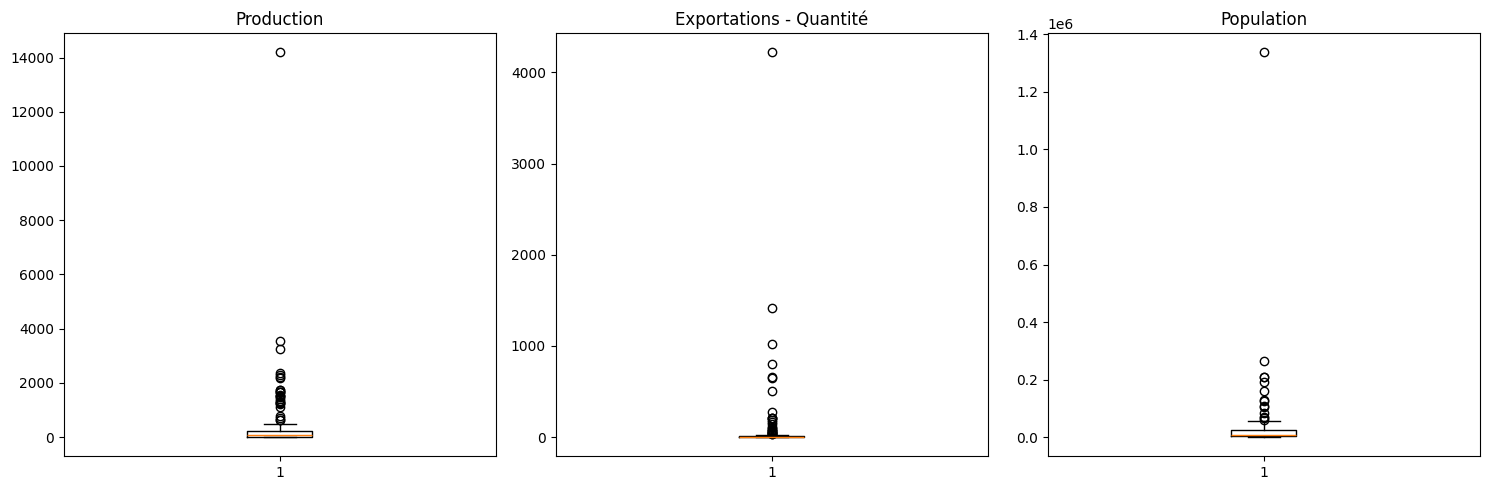

In [ ]:
variables = [
    "Production",
    "Exportations - Quantité",
    "Population"
]

plt.figure(figsize=(15,5))

for i, variable in enumerate(variables):

    plt.subplot(1,3,i+1)

    plt.boxplot(df_final[variable])

    plt.title(variable)

plt.tight_layout()

plt.show()

In [ ]:
df_final.nlargest(5, "Production")[["Zone", "Production"]]

,Zone,Production
20,Brésil,14201.0
57,Inde,3545.0
86,Mexique,3249.0
106,Pologne,2351.0
58,Indonésie,2301.0


In [ ]:
df_final.nlargest(5, "Exportations - Quantité")[
    ["Zone", "Exportations - Quantité"]
]

,Zone,Exportations - Quantité
20,Brésil,4223.0
104,Pays-Bas,1418.0
106,Pologne,1025.0
130,Thaïlande,796.0
16,Belgique,656.0


In [ ]:
df_final.nlargest(5, "Population")[["Zone", "Population"]]

,Zone,Population
57,Inde,1338676.785
58,Indonésie,264650.963
101,Pakistan,207906.209
20,Brésil,207833.823
94,Nigéria,190873.244


## Traitement des valeurs aberrantes

Les boxplots mettent en évidence plusieurs valeurs atypiques. Le **Brésil** se distingue par une production et des exportations exceptionnellement élevées, tandis que l'**Inde** présente une population très supérieure au reste des pays.

Afin de limiter l'influence de ces observations extrêmes sur l'ACP, la Classification Ascendante Hiérarchique (CAH) et le K-Means, ces deux pays sont exclus de l'analyse.

In [ ]:
# Exclusion des observations extrêmes
df_final = df_final[
    ~df_final["Zone"].isin(["Brésil", "Inde"])
].reset_index(drop=True)

## Création d’une copie du jeu de données

Une copie du dataset final a été créée avant le lancement des traitements analytiques.

Cette étape permet de :
- préserver le jeu de données initial ;
- sécuriser les transformations futures ;
- travailler sur une version dédiée aux analyses statistiques et au clustering.

In [ ]:
df_final.isnull().sum()

,0
Zone,0
Disponibilité intérieure,0
Exportations - Quantité,0
Importations - Quantité,0
Production,0
Part_kcal_volaille (%),0
Part_kg_volaille (%),0
Population,0
PIB par habitant,0
Taux d’urbanisation,0


In [ ]:
df_analyse = df_final.copy()

## Vérification finale du jeu de données

Une dernière vérification du dataset a été réalisée avant le lancement des analyses statistiques.

Le jeu de données final :
- contient 146 pays ;
- ne présente aucune valeur manquante ;
- possède uniquement des variables quantitatives exploitables pour l’ACP et le clustering.

Le dataset est désormais prêt pour les analyses exploratoires et multivariées.

In [ ]:
df_analyse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Zone                      143 non-null    object 
 1   Disponibilité intérieure  143 non-null    float64
 2   Exportations - Quantité   143 non-null    float64
 3   Importations - Quantité   143 non-null    float64
 4   Production                143 non-null    float64
 5   Part_kcal_volaille (%)    143 non-null    float64
 6   Part_kg_volaille (%)      143 non-null    float64
 7   Population                143 non-null    float64
 8   PIB par habitant          143 non-null    float64
 9   Taux d’urbanisation       143 non-null    float64
 10  Stabilite_politique       143 non-null    object 
dtypes: float64(9), object(2)
memory usage: 12.4+ KB


In [ ]:
#Quels pays ont une valeur qui ne peut pas être convertie en nombre ?
df_analyse[
    pd.to_numeric(df_analyse["Stabilite_politique"], errors="coerce").isna()
][["Zone", "Stabilite_politique"]]

,Zone,Stabilite_politique
94,Nouvelle-Calédonie,..
105,Polynésie française,..


In [ ]:
#convertion
df_analyse["Stabilite_politique"] = pd.to_numeric(
    df_analyse["Stabilite_politique"], errors="coerce")


In [ ]:
#verification
df_analyse["Stabilite_politique"].isna().sum()

np.int64(2)

In [ ]:
df_analyse[df_analyse["Stabilite_politique"].isna()]

,Zone,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,Part_kcal_volaille (%),Part_kg_volaille (%),Population,PIB par habitant,Taux d’urbanisation,Stabilite_politique
94,Nouvelle-Calédonie,11.0,0.0,9.0,1.0,4.95,6.62,277.150,32354.710283,66.968339,NaN
105,Polynésie française,15.0,0.0,15.0,1.0,5.73,6.98,276.102,20826.931249,61.789694,NaN


In [ ]:
df_analyse["Stabilite_politique"].dtype

dtype('float64')

In [ ]:
df_analyse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Zone                      143 non-null    object 
 1   Disponibilité intérieure  143 non-null    float64
 2   Exportations - Quantité   143 non-null    float64
 3   Importations - Quantité   143 non-null    float64
 4   Production                143 non-null    float64
 5   Part_kcal_volaille (%)    143 non-null    float64
 6   Part_kg_volaille (%)      143 non-null    float64
 7   Population                143 non-null    float64
 8   PIB par habitant          143 non-null    float64
 9   Taux d’urbanisation       143 non-null    float64
 10  Stabilite_politique       141 non-null    float64
dtypes: float64(10), object(1)
memory usage: 12.4+ KB


In [ ]:
df_analyse.loc[[96, 107], ['Zone', 'Stabilite_politique']]

,Zone,Stabilite_politique
96,Népal,56.495173
107,Pérou,62.063368


La Nouvelle-Calédonie et la Polynésie française ne disposent pas d’indicateur de stabilité politique dans la source utilisée.  
Elles sont retirées du dataset d’analyse afin de travailler uniquement avec des données complètes et observées.

In [ ]:
df_analyse.isnull().sum() #verification de valeurs manquants avant l'etape ACP

,0
Zone,0
Disponibilité intérieure,0
Exportations - Quantité,0
Importations - Quantité,0
Production,0
Part_kcal_volaille (%),0
Part_kg_volaille (%),0
Population,0
PIB par habitant,0
Taux d’urbanisation,0


In [ ]:
df_analyse = df_analyse.dropna(subset=['Stabilite_politique'])
#Deux territoires (Nouvelle-Calédonie et Polynésie française) ont été exclus de l'ACP car la source ne fournit pas d'indicateur de stabilité politique pour ces territoires.

In [ ]:
df_analyse.isnull().sum() #verification de valeurs manquants après l'etape de suppression des NaN

,0
Zone,0
Disponibilité intérieure,0
Exportations - Quantité,0
Importations - Quantité,0
Production,0
Part_kcal_volaille (%),0
Part_kg_volaille (%),0
Population,0
PIB par habitant,0
Taux d’urbanisation,0


In [ ]:
df_analyse.to_csv('/content/drive/MyDrive/Colab Notebooks/P11/df_analyse.csv', index=False)